  VIDEO SUMMARIZER & KEYFRAME EXTRACTOR
  Built with OpenCV · NumPy · Matplotlib

📹 VIDEO DATA LOADED:
   · Resolution : 848×384
   · Duration   : 0:01:24
   · FPS        : 44.8
   · Total Frames: 3,796
   · Threshold  : 8.0%
-------------------------------------------------------
⏳ Scanning video for major scene transitions...
✅ Scan complete.
   · Scene changes detected : 53
   · Keyframes selected     : 12
   · Avg frame difference   : 0.67%

📊 Displaying keyframe grid...


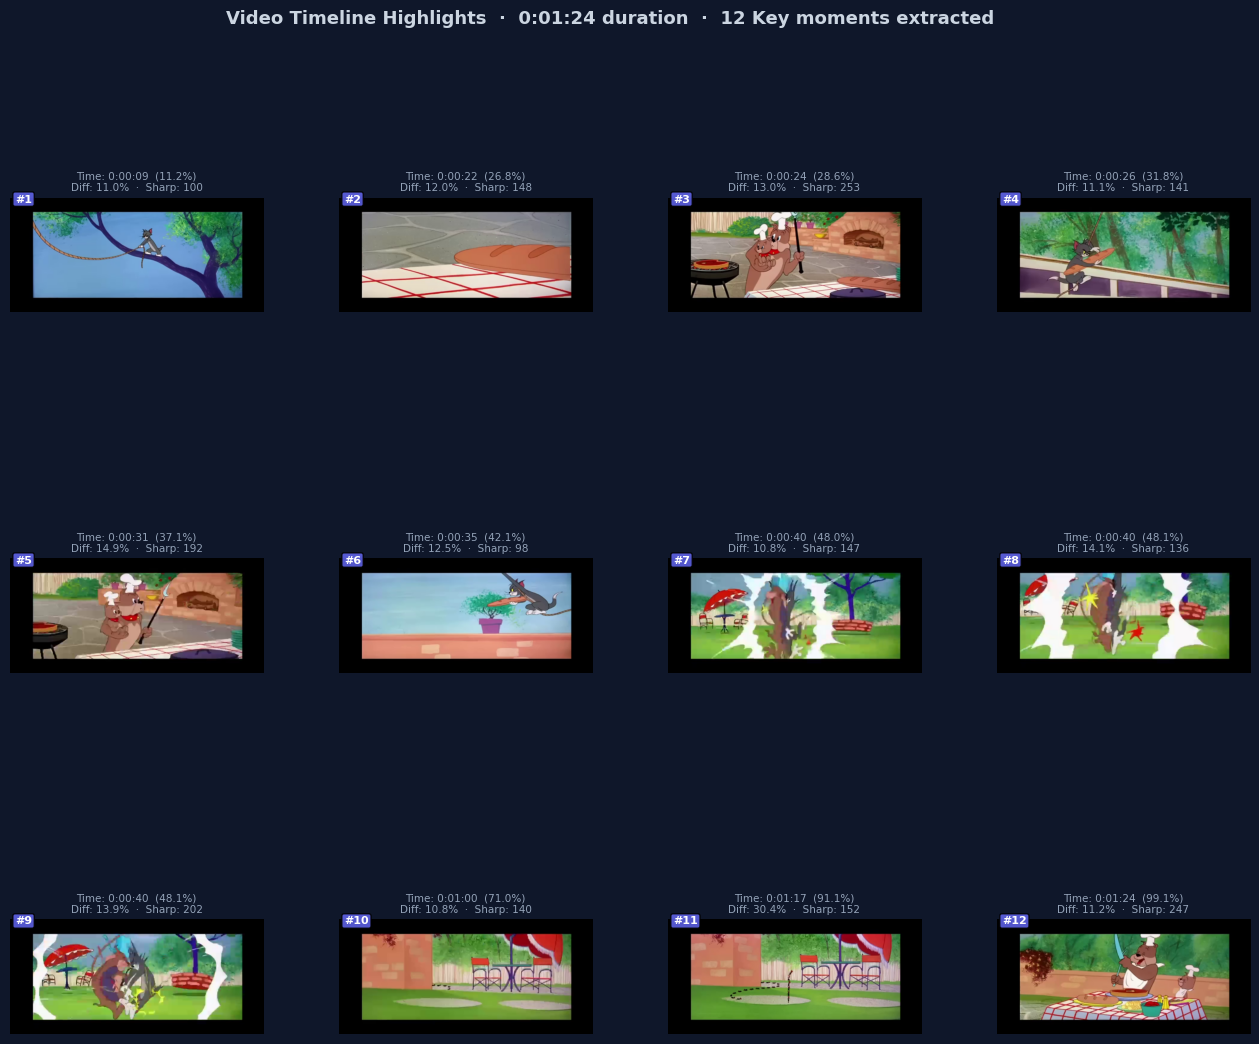

💾 Saved: keyframe_summary.png

📈 Displaying scene timeline...


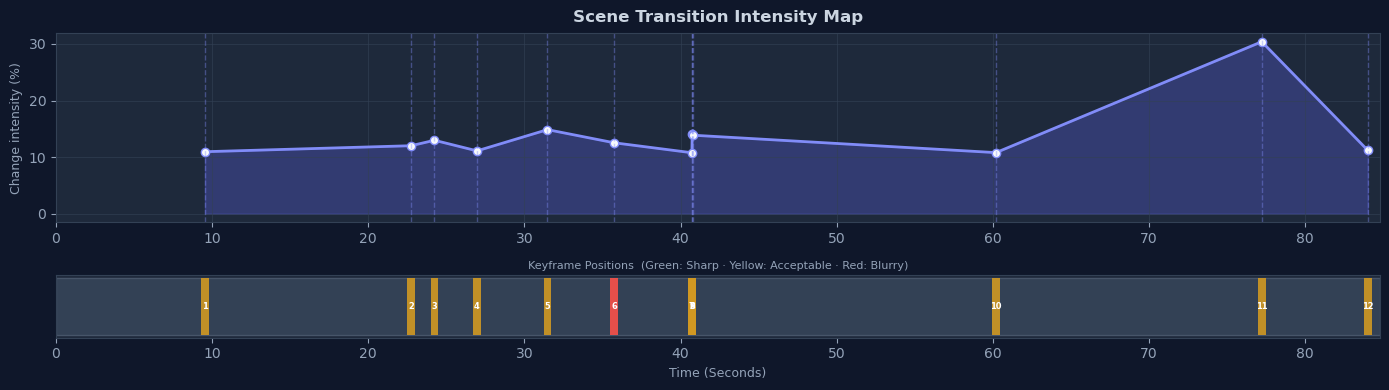

💾 Saved: keyframe_timeline.png

💾 Saving individual images to local directory...
📁 Folder already exists: 'extracted_key_clips/'
💾 Saving individual clip frames to 'extracted_key_clips/'...
🟢 Successfully exported 12 raw JPEGs into the directory.
-------------------------------------------------------

📄 Generating shareable HTML report...
📄 HTML report saved: video_summary_report.html
   Open it in any browser — no Python needed!

QUALITY METRICS AUDIT REPORT
  🟢 Sharp frames    : 0 (0%)
  🟡 Acceptable      : 11 (92%)
  🔴 Blurry frames   : 1 (8%)
  Avg scene change   : 13.8%


In [4]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, HTML
import base64
from datetime import timedelta

# =====================================================================
# 1. CORE MATH & COMPUTER VISION PIPELINE
# =====================================================================

def calculate_frame_difference(frame1, frame2):
    """Calculate how different two consecutive frames are (0-100%)"""
    gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)
    diff = cv2.absdiff(gray1, gray2)
    score = np.mean(diff) / 255.0 * 100
    return round(score, 2)

def calculate_sharpness(frame):
    """
    Laplacian variance — measures image sharpness.
    Higher = sharper. Below 100 = blurry.
    """
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    variance = laplacian.var()
    return round(variance, 1)

def get_sharpness_label(score):
    if score > 500:
        return "🟢 Sharp", "#2ea043"
    elif score > 100:
        return "🟡 Acceptable", "#d29922"
    else:
        return "🔴 Blurry", "#f85149"

def seconds_to_timestamp(seconds):
    """Convert seconds to a clean HH:MM:SS format"""
    return str(timedelta(seconds=int(seconds)))

# =====================================================================
# 2. KEYFRAME EXTRACTION PIPELINE
# =====================================================================

def extract_keyframes(video_path, threshold=8.0, max_frames=12):
    """
    Analyzes video, computes frame difference, monitors scene transitions,
    and returns selected keyframes and structural metadata.
    """
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        print(f"❌ Error: Cannot open video: {video_path}")
        return [], {}
    
    # Video metadata
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total_frames / fps if fps > 0 else 0
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    print("📹 VIDEO DATA LOADED:")
    print(f"   · Resolution : {width}×{height}")
    print(f"   · Duration   : {seconds_to_timestamp(duration)}")
    print(f"   · FPS        : {fps:.1f}")
    print(f"   · Total Frames: {total_frames:,}")
    print(f"   · Threshold  : {threshold}%")
    print("-" * 55)
    
    keyframes = []
    prev_frame = None
    frame_idx = 0
    scene_changes = []
    all_diffs = []
    
    print("⏳ Scanning video for major scene transitions...")
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        if prev_frame is not None:
            diff = calculate_frame_difference(prev_frame, frame)
            all_diffs.append(diff)
            
            if diff > threshold:
                scene_changes.append(frame_idx)
                sharpness = calculate_sharpness(frame)
                timestamp = frame_idx / fps
                
                keyframes.append({
                    'frame_idx': frame_idx,
                    'timestamp': timestamp,
                    'timestamp_str': seconds_to_timestamp(timestamp),
                    'difference': diff,
                    'sharpness': sharpness,
                    'sharpness_label': get_sharpness_label(sharpness),
                    'frame_rgb': cv2.cvtColor(frame, cv2.COLOR_BGR2RGB),
                    'frame_bgr': frame.copy(),
                    'progress_pct': round((frame_idx / total_frames) * 100, 1)
                })
        
        prev_frame = frame.copy()
        frame_idx += 1
    
    cap.release()
    
    # Filter: sort by scene transition weight and keep the top N
    keyframes = sorted(keyframes, key=lambda x: x['difference'], reverse=True)[:max_frames]
    # Re-sort chronologically so they display in timeline order
    keyframes = sorted(keyframes, key=lambda x: x['timestamp'])
    
    print(f"✅ Scan complete.")
    print(f"   · Scene changes detected : {len(scene_changes)}")
    print(f"   · Keyframes selected     : {len(keyframes)}")
    print(f"   · Avg frame difference   : {np.mean(all_diffs):.2f}%")
    
    meta = {
        'fps': fps,
        'duration': duration,
        'total_frames': total_frames,
        'width': width,
        'height': height,
        'scene_changes': len(scene_changes),
        'avg_diff': round(np.mean(all_diffs), 2) if all_diffs else 0
    }
    
    return keyframes, meta

# =====================================================================
# 3. PHYSICAL STORAGE & EXPORT ENGINE
# =====================================================================

def save_keyframes_to_folder(keyframes, folder_name="extracted_key_clips"):
    """
    Physically creates a folder and saves each extracted frame
    as an individual, clean JPEG file to your hard drive.
    """
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)
        print(f"📁 Folder created: '{os.path.abspath(folder_name)}'")
    else:
        print(f"📁 Folder already exists: '{folder_name}/'")
        
    print(f"💾 Saving individual clip frames to '{folder_name}/'...")
    for i, kf in enumerate(keyframes):
        # Clean filesystem colons out of filename timestamps
        safe_time = kf['timestamp_str'].replace(':', '-')
        filename = f"moment_{i+1:02d}_at_{safe_time}.jpg"
        file_path = os.path.join(folder_name, filename)
        
        # Save frame using raw BGR matrix for OpenCV compatibility
        cv2.imwrite(file_path, kf['frame_bgr'])
        
    print(f"🟢 Successfully exported {len(keyframes)} raw JPEGs into the directory.")
    print("-" * 55)

# =====================================================================
# 4. JUPYTER VISUALIZATION GENERATORS
# =====================================================================

def display_keyframe_grid(keyframes, video_meta):
    """Plots extracted keyframes cleanly inside the Jupyter Notebook cell"""
    n = len(keyframes)
    if n == 0:
        print("No keyframes found. Lower your threshold value.")
        return
    
    cols = min(4, n)
    rows = (n + cols - 1) // cols
    
    fig = plt.figure(figsize=(cols * 4, rows * 3.5 + 2))
    fig.patch.set_facecolor('#0f172a') # Slate blue container background
    
    fig.suptitle(
        f'Video Timeline Highlights  ·  {seconds_to_timestamp(video_meta["duration"])} duration  '
        f'·  {n} Key moments extracted',
        color='#cbd5e1', fontsize=13, fontweight='bold', y=0.98
    )
    
    gs = gridspec.GridSpec(rows, cols, figure=fig, hspace=0.5, wspace=0.3)
    
    for i, kf in enumerate(keyframes):
        ax = fig.add_subplot(gs[i // cols, i % cols])
        ax.imshow(kf['frame_rgb'])
        ax.axis('off')
        
        # Sharpness indicator border styling
        sharp_label, sharp_color = kf['sharpness_label']
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(sharp_color)
            spine.set_linewidth(2)
        
        # Removed the ⏱ emoji to prevent Matplotlib layout system warnings on Windows
        ax.set_title(
            f"Time: {kf['timestamp_str']}  ({kf['progress_pct']}%)\n"
            f"Diff: {kf['difference']:.1f}%  ·  Sharp: {kf['sharpness']:.0f}",
            color='#94a3b8',
            fontsize=7.5,
            pad=5
        )
        
        # Badge Overlay
        ax.text(0.02, 0.96, f"#{i+1}",
                transform=ax.transAxes,
                fontsize=8, fontweight='bold',
                color='white',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#6366f1', alpha=0.85))
    
    plt.savefig('keyframe_summary.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
    plt.show()
    print("💾 Saved: keyframe_summary.png")

def display_timeline(keyframes, video_meta):
    """Draws a timeline displaying where transitions occurred"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 4), 
                                    facecolor='#0f172a',
                                    gridspec_kw={'height_ratios': [3, 1]})
    
    duration = video_meta['duration']
    timestamps = [kf['timestamp'] for kf in keyframes]
    diffs      = [kf['difference'] for kf in keyframes]
    
    # Scene change magnitude plot
    ax1.set_facecolor('#1e293b')
    ax1.fill_between(timestamps, diffs, alpha=0.3, color='#6366f1')
    ax1.plot(timestamps, diffs, color='#818cf8', linewidth=2, marker='o',
             markersize=6, markerfacecolor='#f8fafc')
    
    for ts in timestamps:
        ax1.axvline(x=ts, color='#818cf8', alpha=0.4, linewidth=1, linestyle='--')
    
    ax1.set_title('Scene Transition Intensity Map', color='#cbd5e1', fontweight='bold', pad=8)
    ax1.set_ylabel('Change intensity (%)', color='#94a3b8', fontsize=9)
    ax1.tick_params(colors='#94a3b8')
    ax1.set_xlim(0, duration)
    ax1.spines[:].set_color('#334155')
    ax1.grid(True, color='#334155', alpha=0.6)
    
    # Progress positioning bar
    ax2.set_facecolor('#1e293b')
    ax2.barh(0, duration, height=0.4, color='#334155', edgecolor='#475569')
    
    for i, kf in enumerate(keyframes):
        color = '#2ea043' if kf['sharpness'] > 500 else '#d29922' if kf['sharpness'] > 100 else '#f85149'
        ax2.barh(0, 0.5, left=kf['timestamp'] - 0.25, height=0.4, color=color, alpha=0.9)
        ax2.text(kf['timestamp'], 0, f"{i+1}", ha='center', va='center',
                 fontsize=6, color='white', fontweight='bold')
    
    ax2.set_xlim(0, duration)
    ax2.set_xlabel('Time (Seconds)', color='#94a3b8', fontsize=9)
    ax2.set_yticks([])
    ax2.tick_params(colors='#94a3b8')
    ax2.spines[:].set_color('#334155')
    # Replaced unicode colored circles with explicit textual legends to avoid DejaVu Sans font errors
    ax2.set_title('Keyframe Positions  (Green: Sharp · Yellow: Acceptable · Red: Blurry)',
                  color='#94a3b8', fontsize=8, pad=4)
    
    plt.tight_layout()
    plt.savefig('keyframe_timeline.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
    plt.show()
    print("💾 Saved: keyframe_timeline.png")

# =====================================================================
# 5. SHAREABLE REPORT ENGINE
# =====================================================================

def generate_html_report(keyframes, video_meta, output_path='video_summary_report.html'):
    """Generates an offline, portable HTML report with embedded Base64 images"""
    
    def frame_to_base64(frame_rgb):
        frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
        _, buffer = cv2.imencode('.jpg', frame_bgr, [cv2.IMWRITE_JPEG_QUALITY, 85])
        return base64.b64encode(buffer).decode('utf-8')
    
    cards_html = ""
    for i, kf in enumerate(keyframes):
        img_b64 = frame_to_base64(kf['frame_rgb'])
        sharp_label, sharp_color = kf['sharpness_label']
        
        cards_html += f"""
        <div class="card">
            <div class="frame-num">#{i+1}</div>
            <img src="data:image/jpeg;base64,{img_b64}" alt="Keyframe {i+1}">
            <div class="meta">
                <div class="timestamp">⏱ {kf['timestamp_str']}</div>
                <div class="stats">
                    <span>Δ {kf['difference']:.1f}% change</span>
                    <span style="color:{sharp_color}">{sharp_label}</span>
                </div>
                <div class="progress">
                    <div style="width:{kf['progress_pct']}%;height:3px;
                                background:{sharp_color};border-radius:2px"></div>
                </div>
                <div class="progress-label">{kf['progress_pct']}% through video</div>
            </div>
        </div>"""
    
    html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Video Analysis Report</title>
<style>
  body {{ font-family: -apple-system, sans-serif; background:#0f172a; 
          color:#f1f5f9; margin:0; padding:24px; }}
  h1   {{ color:#818cf8; margin-bottom:4px; }}
  .sub {{ color:#94a3b8; font-size:14px; margin-bottom:28px; }}
  .stats-row {{ display:flex; gap:16px; margin-bottom:32px; flex-wrap:wrap; }}
  .stat {{ background:#1e293b; border:1px solid #334155; border-radius:10px;
           padding:16px 24px; text-align:center; min-width:120px; }}
  .stat-val {{ font-size:26px; font-weight:700; color:#818cf8; }}
  .stat-lbl {{ font-size:12px; color:#94a3b8; margin-top:4px; }}
  .grid {{ display:grid; grid-template-columns:repeat(auto-fill,minmax(220px,1fr));
           gap:16px; }}
  .card {{ background:#1e293b; border:1px solid #334155; border-radius:12px;
           overflow:hidden; position:relative; }}
  .frame-num {{ position:absolute; top:10px; left:10px; background:#6366f1;
                color:white; border-radius:6px; padding:2px 8px;
                font-size:11px; font-weight:700; }}
  .card img {{ width:100%; display:block; aspect-ratio:16/9; object-fit:cover; }}
  .meta {{ padding:12px; }}
  .timestamp {{ font-size:15px; font-weight:600; margin-bottom:6px; }}
  .stats {{ display:flex; justify-content:space-between; font-size:11px;
            color:#94a3b8; margin-bottom:8px; }}
  .progress {{ background:#334155; border-radius:2px; height:3px; margin-bottom:4px; }}
  .progress-label {{ font-size:10px; color:#94a3b8; }}
  footer {{ margin-top:40px; text-align:center; color:#94a3b8; font-size:12px; }}
</style>
</head>
<body>
  <h1>🎬 Video Keyframe Analysis Report</h1>
  <p class="sub">Computer Vision analysis using OpenCV · Scene detection + Sharpness scoring</p>
  
  <div class="stats-row">
    <div class="stat">
      <div class="stat-val">{seconds_to_timestamp(video_meta['duration']).replace('-', ':')}</div>
      <div class="stat-lbl">Duration</div>
    </div>
    <div class="stat">
      <div class="stat-val">{video_meta['scene_changes']}</div>
      <div class="stat-lbl">Scene Changes</div>
    </div>
    <div class="stat">
      <div class="stat-val">{len(keyframes)}</div>
      <div class="stat-lbl">Key Moments</div>
    </div>
    <div class="stat">
      <div class="stat-val">{video_meta['fps']:.0f}</div>
      <div class="stat-lbl">FPS</div>
    </div>
    <div class="stat">
      <div class="stat-val">{video_meta['width']}×{video_meta['height']}</div>
      <div class="stat-lbl">Resolution</div>
    </div>
  </div>
  
  <div class="grid">{cards_html}</div>
  
  <footer>
    Generated by Video Summarizer &amp; Keyframe Extractor · 
    Built with Python, OpenCV, NumPy · 
    Eiman Ahmad · AI Portfolio Project
  </footer>
</body>
</html>"""
    
    with open(output_path, 'w', encoding='utf-8') as f:
        f.write(html)
    
    print(f"📄 HTML report saved: {output_path}")
    print(f"   Open it in any browser — no Python needed!")
    return output_path

# =====================================================================
# 6. RUN THE PIPELINE
# =====================================================================

# Paths and Config Setup
VIDEO_PATH = "sample_video.mp4"         # Target video input file
THRESHOLD  = 8.0                        # Sensitivity (Lower splits more keyframes)
MAX_FRAMES = 12                         # Cap limit on image exports
KEYFRAME_FOLDER = "extracted_key_clips" # Name of output folder to generate

# If you don't have a test video, uncomment below to download a default clip:
# os.system('curl -L "https://www.learningcontainer.com/wp-content/uploads/2020/05/sample-mp4-file.mp4" -o sample_video.mp4')

print("=" * 55)
print("  VIDEO SUMMARIZER & KEYFRAME EXTRACTOR")
print("  Built with OpenCV · NumPy · Matplotlib")
print("=" * 55)
print()

result = extract_keyframes(VIDEO_PATH, threshold=THRESHOLD, max_frames=MAX_FRAMES)

if result:
    keyframes, video_meta = result
    
    if keyframes:
        print()
        print("📊 Displaying keyframe grid...")
        display_keyframe_grid(keyframes, video_meta)
        
        print()
        print("📈 Displaying scene timeline...")
        display_timeline(keyframes, video_meta)
        
        print()
        print("💾 Saving individual images to local directory...")
        save_keyframes_to_folder(keyframes, folder_name=KEYFRAME_FOLDER)
        
        print()
        print("📄 Generating shareable HTML report...")
        generate_html_report(keyframes, video_meta)
        
        # Quality Metrics Audit Output
        sharp  = sum(1 for kf in keyframes if kf['sharpness'] > 500)
        medium = sum(1 for kf in keyframes if 100 < kf['sharpness'] <= 500)
        blurry = sum(1 for kf in keyframes if kf['sharpness'] <= 100)
        
        print()
        print("=" * 40)
        print("QUALITY METRICS AUDIT REPORT")
        print("=" * 40)
        print(f"  🟢 Sharp frames    : {sharp} ({sharp/len(keyframes):.0%})")
        print(f"  🟡 Acceptable      : {medium} ({medium/len(keyframes):.0%})")
        print(f"  🔴 Blurry frames   : {blurry} ({blurry/len(keyframes):.0%})")
        print(f"  Avg scene change   : {np.mean([kf['difference'] for kf in keyframes]):.1f}%")
        print("=" * 40)